Dict(:α_b => 0.4, :C => 1.0, :k => 32.5, :T_opt => 265.65, :λ_opt => 0.05, :α_g => 0.1, :DFF => 36.5, :σ => 5.67e-8, :α_I => 0.9, :S => 1368.0, :E => 0.75, :ϕ => 0.028)test
3-dimensional StateSpaceSet{Float64} with 1001 points
[238.49520550966795, 0.2957768116554543, 1.473980247580971]


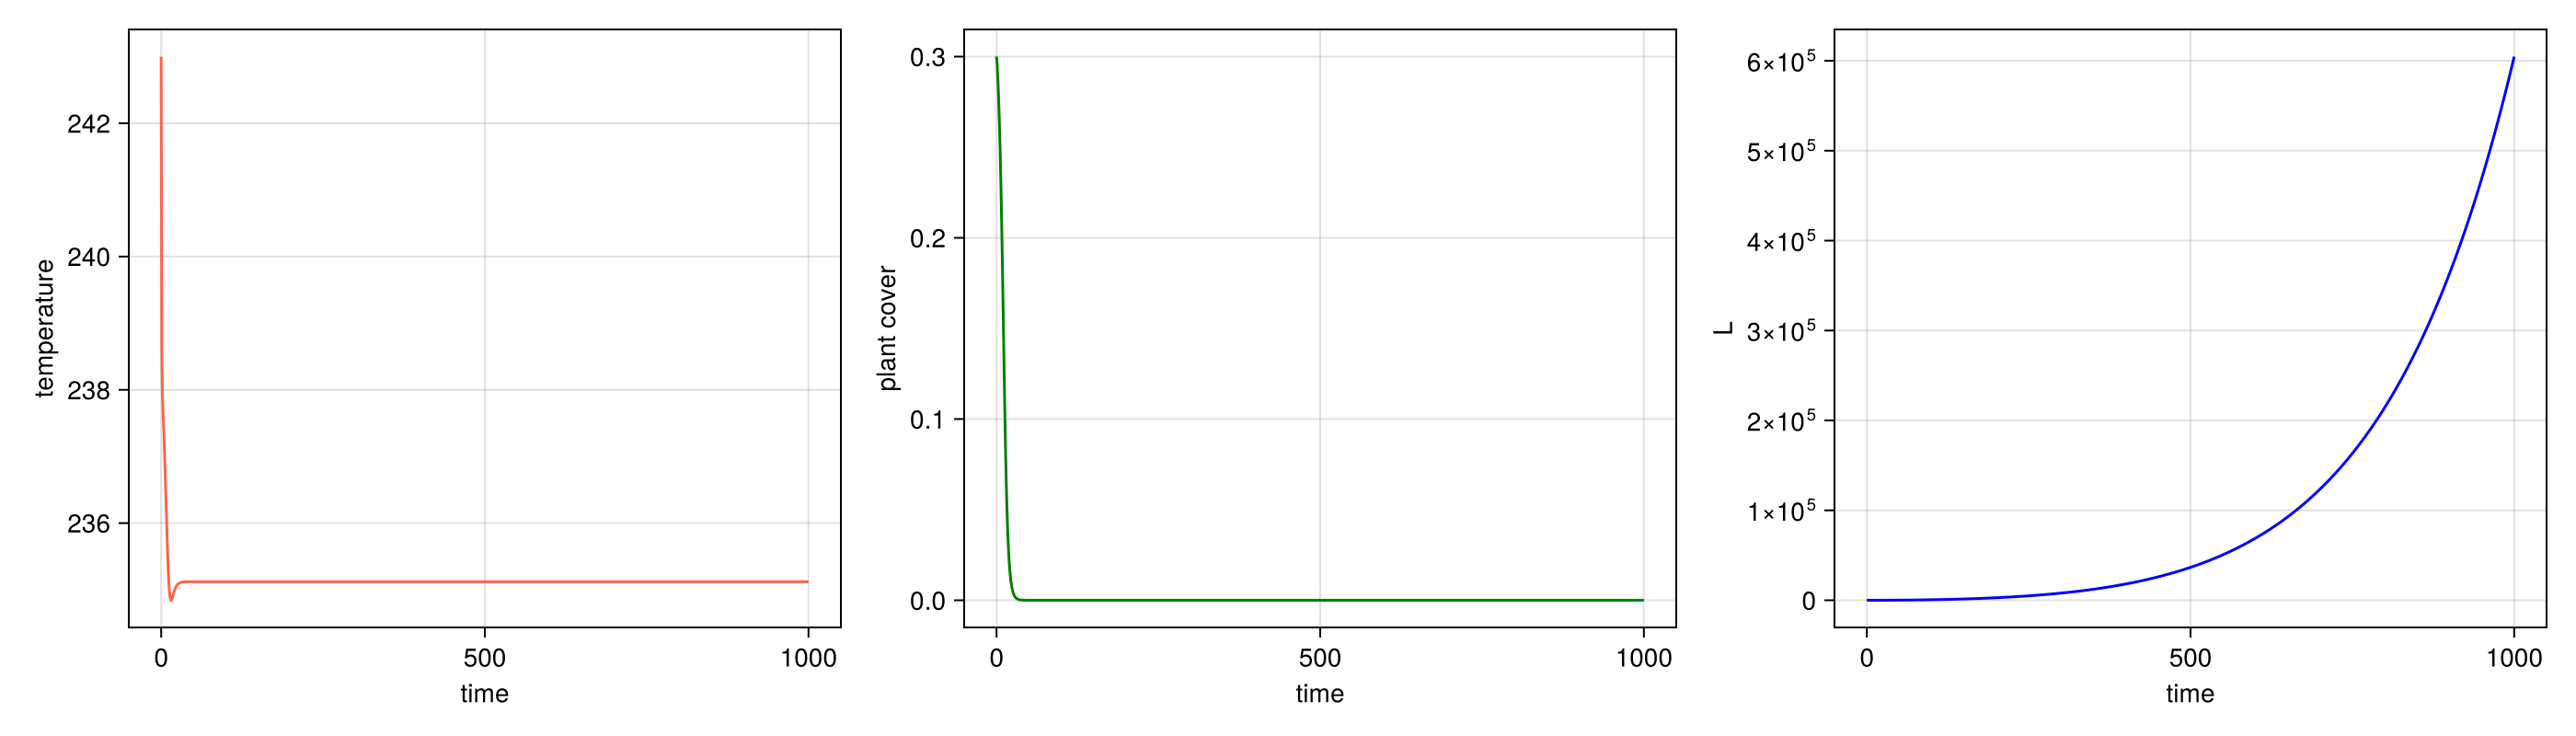

In [22]:
using DynamicalSystemsBase
using CairoMakie

include("model_plantGrowth.jl") 
include("model_glacier.jl")

function antarctica(u,p,t)
    T,b,L = u

    p = NamedTuple(p) # Whenever p.n is called, n is defined in the Dict
    
    I = 0.65 #Change this to be based on L
    g = 1 - I - b # Vacant space

    α_tot = p.α_b * b * g + p.α_I * I + p.α_g * g #Total albedo is the albedo added up
    ϵ = p.E + b * p.ϕ  # Emmisivity
        
    dT = (p.S / 4 ) * (1 - α_tot) - ϵ * p.σ * T^4 / p.C
    λ_b = loss_b(T, p.T_opt, p.k, p.λ_opt)
    β_b = growth_b(T, p.T_opt, p.k)
    db = b * (g*(β_b - λ_b))
    #db = b * (g * β_b - p.λ_b)
    dL = change_ice(L, T) 
    #These are the differential equations

    return SVector(dT,db,dL)
end

p = Dict(
    :σ => (5.670)*10^(-8), #Stefanboltzman constante
    :S => 1368.0,    #Solar impact (energy from sun)
    
    #Constants we can tweak
    :α_b => 0.4,   # Albedo (reflectivity) value of the plants
    :α_I => 0.9,   # Albedo of the ice
    :α_g => 0.1,   # Albedo of the ground
    :λ_opt => 0.05,     # Loss rate of plants
    :E => 0.75,     # Default emmisivity of the atmosphere, without plants
    :ϕ => 0.028,    # Effectivity of the plants on emmisivity 
    :k => 32.5,      # Survivavable deviation in temperature wherein plants can still reproduce 
    :T_opt => 265.65, # Optimal temperature for plant reproducition
    :C => 1.0,        # Time scale for the dT function 
    :DFF => 0.1 * 365 #Ice growth surface area 
    )
 
   
print(p)

u0 = [243.0, 0.3, 1.0] #Starting value of T, b, L
t0 = 0.0 #Starting time
ds = CoupledODEs(antarctica, u0, p) #Runs the function over time

t_total = 1000.0
dt = 1.0 
#dt is how much you increment time each calculation, and t_total is when it stops
X, t = trajectory(ds, t_total; Δt=dt)

println("test")
println(X)

println(X[2])

X_columns = columns(X) #X is a matrix of results, columns seperates these
#println(X_columns[1])


fig = Figure(size=(1400,400))

ax_temp = Axis(fig[1, 1]; xlabel = "time", ylabel = "temperature") 
ax_plant = Axis(fig[1,2]; xlabel = "time", ylabel = "plant cover")
ax_ice = Axis(fig[1,3]; xlabel = "time", ylabel = "L")

lines!(ax_temp, t, X_columns[1], color = :tomato)
lines!(ax_plant, t, X_columns[2], color = :green)
lines!(ax_ice, t, X_columns[3], color = :blue)

fig